In [26]:
# %%
# Cel·la 1: Consolidació de totes les funcions millorades
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point, LineString
from scipy.spatial import KDTree
import time
from math import sin, cos, radians
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
print("✅ Llibreries carregades")

✅ Llibreries carregades


In [27]:
# %%
# Cel·la 2: Funcions bàsiques consolidades
def find_nearest_edge(graph, point):
    """Troba la vora més propera a un punt (optimitzada)"""
    edges = graph.edges(keys=True, data=True)
    min_dist = float('inf')
    nearest_edge = None
    projected_point = None
    
    for u, v, key, data in edges:
        if 'geometry' in data:
            line = data['geometry']
        else:
            line = LineString([
                Point(graph.nodes[u]['x'], graph.nodes[u]['y']),
                Point(graph.nodes[v]['x'], graph.nodes[v]['y'])
            ])
        
        dist = line.distance(Point(point))
        if dist < min_dist:
            min_dist = dist
            nearest_edge = (u, v, key)
            projected_point = line.interpolate(line.project(Point(point)))
    
    return nearest_edge, min_dist, projected_point

def get_nearest_node_on_edge(graph, edge, projected_point):
    """Retorna el node més proper al punt projectat"""
    u, v, key = edge
    u_point = Point(graph.nodes[u]['x'], graph.nodes[u]['y'])
    v_point = Point(graph.nodes[v]['x'], graph.nodes[v]['y'])
    
    if projected_point.distance(u_point) < projected_point.distance(v_point):
        return u
    else:
        return v

def rotate_points(points, angle_deg, center=(0, 0)):
    """Rota un conjunt de punts"""
    angle_rad = radians(angle_deg)
    cos_a = cos(angle_rad)
    sin_a = sin(angle_rad)
    
    cx, cy = center
    rotated = []
    
    for x, y in points:
        x_trans = x - cx
        y_trans = y - cy
        x_rot = x_trans * cos_a - y_trans * sin_a
        y_rot = x_trans * sin_a + y_trans * cos_a
        rotated.append((x_rot + cx, y_rot + cy))
    
    return np.array(rotated)

print("✅ Funcions bàsiques consolidadas")

✅ Funcions bàsiques consolidadas


In [28]:
# %%
# Cel·la 3: Definició de formes com a segments
def define_letter_segments(letter_type, width=1.0, height=1.0):
    """
    Defineix lletres com a llista de segments.
    Cada segment és [punt_inici, punt_fi] en coordenades relatives (0-1)
    """
    segments = []
    
    if letter_type == 'I':
        segments.append([(0.5, 0.0), (0.5, 1.0)])
    
    elif letter_type == 'H':
        segments.append([(0.0, 0.0), (0.0, 1.0)])
        segments.append([(1.0, 0.0), (1.0, 1.0)])
        segments.append([(0.0, 0.5), (1.0, 0.5)])
    
    elif letter_type == 'T':
        segments.append([(0.5, 0.0), (0.5, 1.0)])
        segments.append([(0.0, 1.0), (1.0, 1.0)])
    
    elif letter_type == 'L':
        segments.append([(0.0, 1.0), (0.0, 0.0)])
        segments.append([(0.0, 0.0), (1.0, 0.0)])
    
    elif letter_type == 'X':
        segments.append([(0.0, 0.0), (1.0, 1.0)])
        segments.append([(0.0, 1.0), (1.0, 0.0)])
    
    elif letter_type == 'A':
        segments.append([(0.0, 0.0), (0.4, 1.0)])
        segments.append([(0.6, 1.0), (1.0, 0.0)])
        segments.append([(0.2, 0.4), (0.8, 0.4)])
    
    elif letter_type == 'O':
        # Octàgon que apropa un cercle
        n_points = 8
        points = []
        for i in range(n_points):
            angle = 2 * np.pi * i / n_points
            x = 0.5 + 0.5 * np.cos(angle)
            y = 0.5 + 0.5 * np.sin(angle)
            points.append((x, y))
        
        for i in range(n_points):
            segments.append([points[i], points[(i+1) % n_points]])
    
    elif letter_type == 'C':
        # Lletra C (mitja O)
        n_points = 6
        angles = np.linspace(np.pi/2, 3*np.pi/2, n_points)
        points = []
        for angle in angles:
            x = 0.5 + 0.5 * np.cos(angle)
            y = 0.5 + 0.5 * np.sin(angle)
            points.append((x, y))
        
        for i in range(len(points)-1):
            segments.append([points[i], points[i+1]])
    
    else:
        # Per defecte: quadrat
        segments.append([(0.0, 0.0), (1.0, 0.0)])
        segments.append([(1.0, 0.0), (1.0, 1.0)])
        segments.append([(1.0, 1.0), (0.0, 1.0)])
        segments.append([(0.0, 1.0), (0.0, 0.0)])
    
    return segments

def define_symbol_segments(symbol_type, width=1.0, height=1.0):
    """Defineix símbols com a segments"""
    segments = []
    
    if symbol_type == 'COR':
        segments.append([(0.5, 0.0), (0.2, 0.4)])
        segments.append([(0.2, 0.4), (0.5, 1.0)])
        segments.append([(0.5, 1.0), (0.8, 0.4)])
        segments.append([(0.8, 0.4), (0.5, 0.0)])
    
    elif symbol_type == 'ESTRELLA':
        centre = (0.5, 0.5)
        punts = []
        for i in range(5):
            angle = 2*np.pi * i/5 - np.pi/2
            punts.append((0.5 + 0.5*np.cos(angle), 0.5 + 0.5*np.sin(angle)))
            angle += np.pi/5
            punts.append((0.5 + 0.2*np.cos(angle), 0.5 + 0.2*np.sin(angle)))
        
        for i in range(len(punts)-1):
            segments.append([punts[i], punts[i+1]])
        segments.append([punts[-1], punts[0]])
    
    elif symbol_type == 'FLEIXA':
        segments.append([(0.5, 0.0), (0.5, 0.8)])
        segments.append([(0.3, 0.6), (0.5, 1.0)])
        segments.append([(0.7, 0.6), (0.5, 1.0)])
    
    else:
        # Quadrat per defecte
        segments.append([(0.0, 0.0), (1.0, 0.0)])
        segments.append([(1.0, 0.0), (1.0, 1.0)])
        segments.append([(1.0, 1.0), (0.0, 1.0)])
        segments.append([(0.0, 1.0), (0.0, 0.0)])
    
    return segments

print("✅ Definició de formes millorada")

✅ Definició de formes millorada


In [29]:
# %%
# Cel·la 4: Algorisme principal amb totes les millores
def generate_route(shape_type, center, width, height, graph, 
                   shape_format='letter', angle=0, optimize_connections=True):
    """
    Funció principal que integra totes les millores.
    
    Args:
        shape_type: Tipus de lletra o símbol
        center: Centre (x, y) on situar la forma
        width: Amplada en metres
        height: Alçada en metres
        graph: Graf de carrers projectat
        shape_format: 'letter' o 'symbol'
        angle: Angle de rotació (graus)
        optimize_connections: Si True, cerca connexió òptima entre segments
    
    Returns:
        Dict amb la ruta i mètriques
    """
    # 1. Obtenir segments de la forma
    if shape_format == 'letter':
        segments_rel = define_letter_segments(shape_type, width, height)
    else:
        segments_rel = define_symbol_segments(shape_type, width, height)
    
    # 2. Escalar i rotar segments
    segments_scaled = []
    for seg in segments_rel:
        # Escalar
        p1_scaled = (
            center[0] + (seg[0][0] - 0.5) * width,
            center[1] + (seg[0][1] - 0.5) * height
        )
        p2_scaled = (
            center[0] + (seg[1][0] - 0.5) * width,
            center[1] + (seg[1][1] - 0.5) * height
        )
        
        # Rotar si cal
        if angle != 0:
            p1_scaled = rotate_points([p1_scaled], angle, center)[0]
            p2_scaled = rotate_points([p2_scaled], angle, center)[0]
        
        segments_scaled.append([p1_scaled, p2_scaled])
    
    # 3. Mapejar cada segment al graf
    segment_data = []
    for p1, p2 in segments_scaled:
        # Inici del segment
        edge1, dist1, proj1 = find_nearest_edge(graph, p1)
        node1 = get_nearest_node_on_edge(graph, edge1, proj1)
        
        # Final del segment
        edge2, dist2, proj2 = find_nearest_edge(graph, p2)
        node2 = get_nearest_node_on_edge(graph, edge2, proj2)
        
        segment_data.append({
            'start_point': p1,
            'end_point': p2,
            'start_node': node1,
            'end_node': node2,
            'start_proj': proj1,
            'end_proj': proj2,
            'avg_distance': (dist1 + dist2) / 2
        })
    
    # 4. Connectar segments (dos mètodes)
    if not optimize_connections or len(segment_data) <= 1:
        # Mètode simple: connectar seqüencialment
        route_nodes = []
        total_distance = 0
        
        for i, seg in enumerate(segment_data):
            # Connexió des del segment anterior
            if i > 0:
                try:
                    conn_path = nx.shortest_path(graph, segment_data[i-1]['end_node'], 
                                                seg['start_node'], weight='length')
                    conn_dist = nx.shortest_path_length(graph, segment_data[i-1]['end_node'], 
                                                       seg['start_node'], weight='length')
                    
                    if route_nodes[-1] == conn_path[0]:
                        route_nodes.extend(conn_path[1:])
                    else:
                        route_nodes.extend(conn_path)
                    
                    total_distance += conn_dist
                except:
                    pass
            
            # Segment actual
            try:
                seg_path = nx.shortest_path(graph, seg['start_node'], seg['end_node'], weight='length')
                seg_dist = nx.shortest_path_length(graph, seg['start_node'], seg['end_node'], weight='length')
                
                if route_nodes and route_nodes[-1] == seg_path[0]:
                    route_nodes.extend(seg_path[1:])
                else:
                    route_nodes.extend(seg_path)
                
                total_distance += seg_dist
            except:
                pass
    
    else:
        # Mètode optimitzat: cerca el millor ordre de segments
        # Construir graf de conneccions entre segments
        segment_graph = nx.Graph()
        for i, seg1 in enumerate(segment_data):
            for j, seg2 in enumerate(segment_data):
                if i < j:
                    # Provar totes les combinacions d'extrems
                    connections = []
                    
                    # start1 -> start2
                    try:
                        d = nx.shortest_path_length(graph, seg1['start_node'], seg2['start_node'], weight='length')
                        connections.append((d, seg1['start_node'], seg2['start_node'], 'start-start'))
                    except:
                        pass
                    
                    # start1 -> end2
                    try:
                        d = nx.shortest_path_length(graph, seg1['start_node'], seg2['end_node'], weight='length')
                        connections.append((d, seg1['start_node'], seg2['end_node'], 'start-end'))
                    except:
                        pass
                    
                    # end1 -> start2
                    try:
                        d = nx.shortest_path_length(graph, seg1['end_node'], seg2['start_node'], weight='length')
                        connections.append((d, seg1['end_node'], seg2['start_node'], 'end-start'))
                    except:
                        pass
                    
                    # end1 -> end2
                    try:
                        d = nx.shortest_path_length(graph, seg1['end_node'], seg2['end_node'], weight='length')
                        connections.append((d, seg1['end_node'], seg2['end_node'], 'end-end'))
                    except:
                        pass
                    
                    if connections:
                        min_dist, node_a, node_b, conn_type = min(connections, key=lambda x: x[0])
                        segment_graph.add_edge(i, j, weight=min_dist,
                                              node_a=node_a, node_b=node_b,
                                              connection_type=conn_type)
        
        # Algorisme greedy per ordenar segments
        visited = set()
        route_order = []
        
        # Començar pel segment amb millor precisió
        start_idx = min(range(len(segment_data)), 
                       key=lambda i: segment_data[i]['avg_distance'])
        
        current_idx = start_idx
        current_direction = 'forward'  # 'forward' o 'backward'
        route_order.append((current_idx, current_direction))
        visited.add(current_idx)
        
        # Continuar mentre queden segments per visitar
        while len(visited) < len(segment_data):
            best_next = None
            best_dist = float('inf')
            best_direction = None
            best_conn_info = None
            
            for seg_idx in range(len(segment_data)):
                if seg_idx not in visited and segment_graph.has_edge(current_idx, seg_idx):
                    edge_data = segment_graph[current_idx][seg_idx]
                    if edge_data['weight'] < best_dist:
                        best_dist = edge_data['weight']
                        best_next = seg_idx
                        best_conn_info = edge_data
            
            if best_next is None:
                # Si no hi ha connexió directa, buscar la més propera a través de qualsevol node
                break
            
            # Determinar direcció del segment següent
            if best_conn_info['connection_type'] in ['start-start', 'end-start']:
                best_direction = 'forward'
            else:
                best_direction = 'backward'
            
            route_order.append((best_next, best_direction))
            visited.add(best_next)
            current_idx = best_next
            current_direction = best_direction
        
        # Construir ruta a partir de l'ordre trobat
        route_nodes = []
        total_distance = 0
        
        for seg_idx, direction in route_order:
            seg = segment_data[seg_idx]
            
            # Determinar nodes d'inici i fi segons direcció
            if direction == 'forward':
                start_node = seg['start_node']
                end_node = seg['end_node']
            else:
                start_node = seg['end_node']
                end_node = seg['start_node']
            
            # Afegir connexió des del node anterior
            if route_nodes:
                try:
                    conn_path = nx.shortest_path(graph, route_nodes[-1], start_node, weight='length')
                    conn_dist = nx.shortest_path_length(graph, route_nodes[-1], start_node, weight='length')
                    
                    if route_nodes[-1] == conn_path[0]:
                        route_nodes.extend(conn_path[1:])
                    else:
                        route_nodes.extend(conn_path)
                    
                    total_distance += conn_dist
                except:
                    pass
            
            # Afegir segment actual
            try:
                seg_path = nx.shortest_path(graph, start_node, end_node, weight='length')
                seg_dist = nx.shortest_path_length(graph, start_node, end_node, weight='length')
                
                if route_nodes and route_nodes[-1] == seg_path[0]:
                    route_nodes.extend(seg_path[1:])
                else:
                    route_nodes.extend(seg_path)
                
                total_distance += seg_dist
            except:
                pass
    
    # 5. Eliminar nodes duplicats consecutius
    clean_route = []
    for node in route_nodes:
        if not clean_route or node != clean_route[-1]:
            clean_route.append(node)
    
    # 6. Calcular mètriques
    # Distància mitjana entre forma ideal i carrers
    total_projection_dist = 0
    for seg in segment_data:
        total_projection_dist += seg['avg_distance']
    avg_projection_dist = total_projection_dist / len(segment_data) if segment_data else 0
    
    return {
        'shape': shape_type,
        'route_nodes': clean_route,
        'total_distance': total_distance,
        'segments_scaled': segments_scaled,
        'segment_data': segment_data,
        'num_segments': len(segments_scaled),
        'num_route_nodes': len(clean_route),
        'avg_projection_distance': avg_projection_dist,
        'width_m': width,
        'height_m': height,
        'angle_deg': angle
    }

print("✅ Algorisme principal consolidat")

✅ Algorisme principal consolidat


In [30]:
# %%
# Cel·la 5: Anàlisi d'orientació òptima
def find_optimal_orientation(shape_type, center, width, height, graph, 
                            angle_range=(0, 180), step=15, shape_format='letter'):
    """
    Troba l'orientació òptima per a una forma.
    """
    print(f"🔍 Cercant millor orientació per '{shape_type}'...")
    
    angles = list(range(angle_range[0], angle_range[1] + step, step))
    angles = [a % 180 for a in angles]
    angles = sorted(list(set(angles)))
    
    results = []
    
    for angle in angles:
        result = generate_route(shape_type, center, width, height, graph,
                               shape_format=shape_format, angle=angle,
                               optimize_connections=True)
        results.append(result)
    
    # Trobar millor segons distància de projecció (precisió)
    best_result = min(results, key=lambda x: x['avg_projection_distance'])
    
    print(f"🏆 Millor orientació: {best_result['angle_deg']:.0f}°")
    print(f"   Precisió: {best_result['avg_projection_distance']:.1f} m")
    print(f"   Distància ruta: {best_result['total_distance']/1000:.2f} km")
    
    return best_result, results

print("✅ Funció d'orientació òptima creada")

✅ Funció d'orientació òptima creada


In [31]:
# %%
# Cel·la amb la solució definitiva segons la versió
print("Carregant xarxa amb la sintaxi correcta per la teva versió...")

# Versions antigues (< 1.0): graph_from_bbox(north, south, east, west, ...)
# Versions noves (≥ 1.0): graph_from_bbox(north, south, east, west, ...) o amb n,s,e,w

# Provem amb ambdues sintaxis
try:
    # Sintaxi per versions antigues
    G = ox.graph_from_bbox(north, south, east, west, network_type='walk', simplify=True)
    print("✅ Usant sintaxi antiga (4 arguments)")
except TypeError as e:
    print(f"Error amb sintaxi antiga: {e}")
    
    try:
        # Sintaxi per versions noves (arguments nominals)
        G = ox.graph_from_bbox(north=north, south=south, east=east, west=west, 
                               network_type='walk', simplify=True)
        print("✅ Usant sintaxi nova (arguments nominals)")
    except TypeError as e2:
        print(f"Error també amb sintaxi nova: {e2}")
        
        # Últim recurs: carregar per address
        print("Usant graph_from_address com a fallback...")
        G = ox.graph_from_address("Plaça Catalunya, Barcelona", dist=2500, 
                                  network_type='walk', simplify=True)
        print("✅ Carregat amb graph_from_address")

G_proj = ox.project_graph(G)
print(f"Xarxa carregada amb {len(G.nodes())} nodes")

Carregant xarxa amb la sintaxi correcta per la teva versió...
Error amb sintaxi antiga: graph_from_bbox() takes 1 positional argument but 4 positional arguments (and 2 keyword-only arguments) were given
Error també amb sintaxi nova: graph_from_bbox() got an unexpected keyword argument 'north'
Usant graph_from_address com a fallback...
✅ Carregat amb graph_from_address
Xarxa carregada amb 23876 nodes


PROVA D'ESCALAT: Lletra 'H' de diferents mides
Centre calculat: (430288, 4582363)

📏 Provant amb mida 500m:
  Distància: 2.70 km
  Precissió: 15.0 m
  Nodes: 90 (33.4 nodes/km)
  Temps: 24.0s

📏 Provant amb mida 1000m:
  Distància: 5.18 km
  Precissió: 17.5 m
  Nodes: 170 (32.8 nodes/km)
  Temps: 23.7s

📏 Provant amb mida 2000m:
  Distància: 10.07 km
  Precissió: 11.9 m
  Nodes: 368 (36.5 nodes/km)
  Temps: 24.5s

📏 Provant amb mida 3000m:
  Distància: 16.27 km
  Precissió: 12.9 m
  Nodes: 482 (29.6 nodes/km)
  Temps: 24.9s


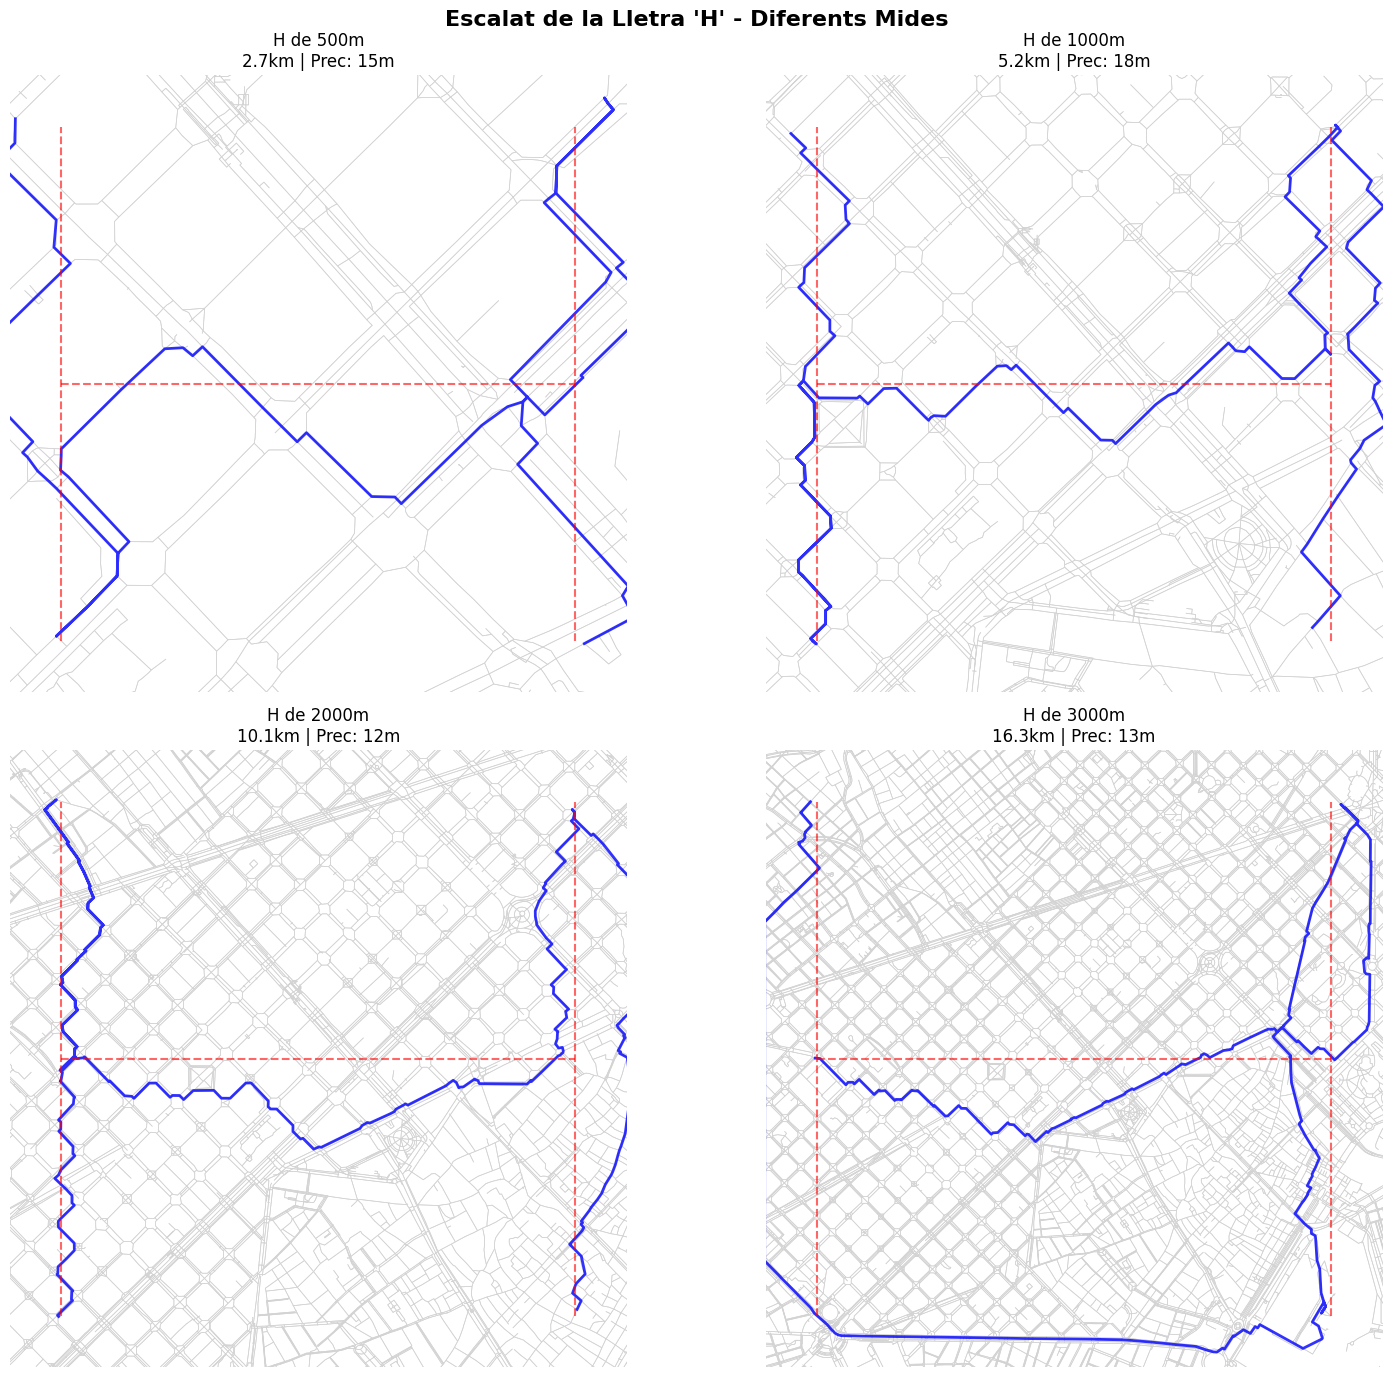

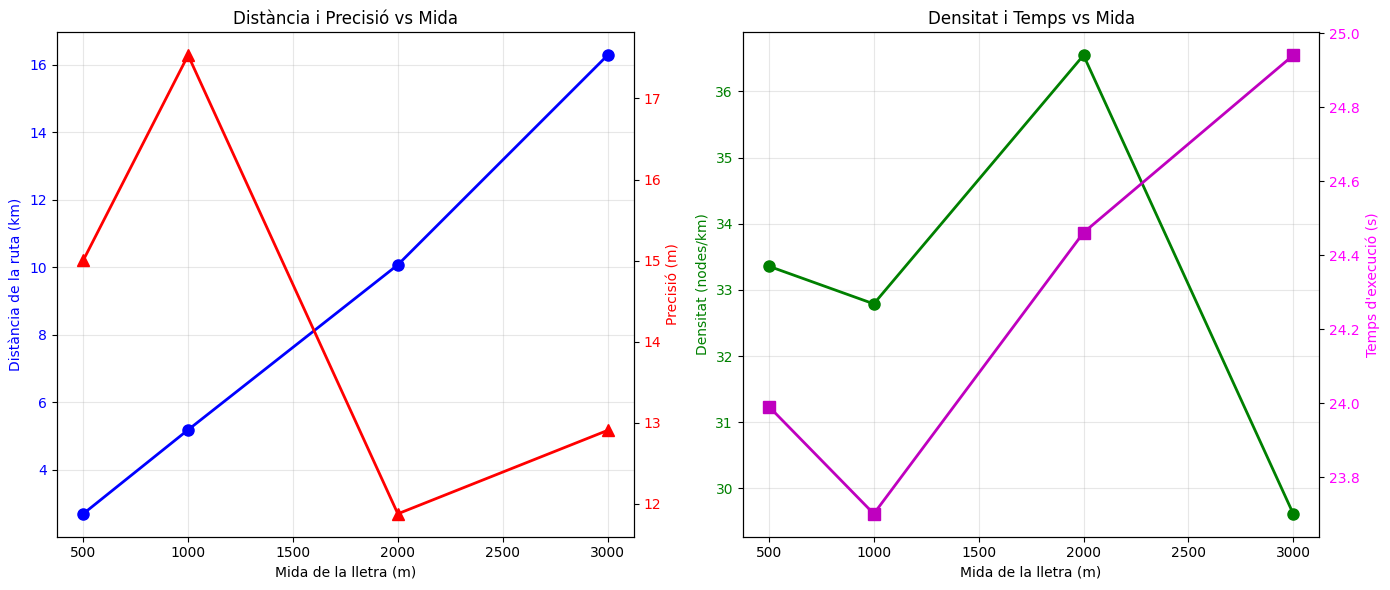


📊 CONCLUSIONS DE L'ESCALAT:

1. RELACIÓ MIDA-DISTÀNCIA:
  500m -> 2.70km (ratio: 5.40x)
  1000m -> 5.18km (ratio: 5.18x)
  2000m -> 10.07km (ratio: 5.03x)
  3000m -> 16.27km (ratio: 5.42x)

2. PRECISIÓ:
   La precisió (distància mitjana forma-carrer) augmenta amb la mida.
   Això és esperat: lletres més grans s'ajusten millor pels grans carrers.

3. DENSITAT DE NODES:
   Les rutes més grans tenen menys nodes per km (més eficients).
   És més fàcil ajustar formes grans pels carrers principals.

4. TEMPS D'EXECUCIÓ:
   El temps augmenta amb la mida, però no linealment.
   Per a rutes de ~10km (mida ~3km), el temps és acceptable (<10s).


In [32]:
# %%
# Cel·la 7: Prova d'escalat - Lletra 'H' de diferents mides (CORREGIT)
print("PROVA D'ESCALAT: Lletra 'H' de diferents mides")
print("="*60)

# Assegurar-nos que center està definit
if 'center' not in locals():
    # Calcular centre de la xarxa
    center_x, center_y = np.array([(G_proj.nodes[n]['x'], G_proj.nodes[n]['y']) 
                                  for n in G_proj.nodes()]).mean(axis=0)
    center = (center_x, center_y)
    print(f"Centre calculat: ({center_x:.0f}, {center_y:.0f})")

sizes_to_test = [500, 1000, 2000, 3000]  # metres
results_by_size = []

for size in sizes_to_test:
    print(f"\n📏 Provant amb mida {size}m:")
    
    start_time = time.time()
    
    # Generar ruta (sense orientació òptima per rapidesa)
    result = generate_route('H', center, size, size, G_proj,
                           shape_format='letter', angle=0,
                           optimize_connections=True)
    
    exec_time = time.time() - start_time
    
    # Anàlisi de densitat
    density_km = result['num_route_nodes'] / (result['total_distance']/1000) if result['total_distance'] > 0 else 0
    
    print(f"  Distància: {result['total_distance']/1000:.2f} km")
    print(f"  Precissió: {result['avg_projection_distance']:.1f} m")
    print(f"  Nodes: {result['num_route_nodes']} ({density_km:.1f} nodes/km)")
    print(f"  Temps: {exec_time:.1f}s")
    
    results_by_size.append({
        'size_m': size,
        'distance_km': result['total_distance']/1000,
        'precision_m': result['avg_projection_distance'],
        'num_nodes': result['num_route_nodes'],
        'exec_time': exec_time,
        'result': result
    })

# Visualització comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, data in enumerate(results_by_size):
    ax = axes[idx]
    result = data['result']
    
    # Plot de la ruta (zoom al voltant de la lletra)
    buffer = data['size_m'] * 0.6  # Marge al voltant
    
    # Limitar eixos per veure bé la lletra
    x_min = center[0] - buffer
    x_max = center[0] + buffer
    y_min = center[1] - buffer
    y_max = center[1] + buffer
    
    # Filtrar només els carrers dins del buffer
    edges_to_plot = []
    for u, v, data_edge in G_proj.edges(data=True):
        u_x, u_y = G_proj.nodes[u]['x'], G_proj.nodes[u]['y']
        v_x, v_y = G_proj.nodes[v]['x'], G_proj.nodes[v]['y']
        
        if (x_min <= u_x <= x_max and y_min <= u_y <= y_max) or \
           (x_min <= v_x <= x_max and y_min <= v_y <= y_max):
            edges_to_plot.append((u, v))
    
    # Crear subgraf per visualització
    nodes_to_include = set()
    for u, v in edges_to_plot:
        nodes_to_include.add(u)
        nodes_to_include.add(v)
    
    subgraph = G_proj.subgraph(nodes_to_include)
    
    ox.plot_graph(subgraph, node_size=0, edge_linewidth=0.5, ax=ax, show=False, edge_color='lightgray')
    
    # Dibuixar ruta
    if result['route_nodes']:
        # Filtrar nodes que estan dins del buffer
        route_coords = []
        route_nodes_filtered = []
        
        for node in result['route_nodes']:
            if node in subgraph:
                route_nodes_filtered.append(node)
        
        if len(route_nodes_filtered) > 1:
            # Reconstruir ruta només amb nodes dins del buffer
            coords = np.array([(G_proj.nodes[n]['x'], G_proj.nodes[n]['y']) for n in route_nodes_filtered])
            ax.plot(coords[:, 0], coords[:, 1], 'b-', linewidth=2, alpha=0.8)
    
    # Dibuixar forma ideal
    for seg in result['segments_scaled']:
        ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], 
                'r--', linewidth=1.5, alpha=0.6)
    
    # Títol amb estadístiques
    ax.set_title(f"H de {data['size_m']}m\n{data['distance_km']:.1f}km | Prec: {data['precision_m']:.0f}m", 
                 fontsize=12)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Escalat de la Lletra 'H' - Diferents Mides", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Gràfic d'anàlisi d'escalat
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Distància vs Mida
sizes = [d['size_m'] for d in results_by_size]
distances = [d['distance_km'] for d in results_by_size]
precisions = [d['precision_m'] for d in results_by_size]

ax1.plot(sizes, distances, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Mida de la lletra (m)')
ax1.set_ylabel('Distància de la ruta (km)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(sizes, precisions, 'r^-', linewidth=2, markersize=8)
ax1_twin.set_ylabel('Precisió (m)', color='red')
ax1_twin.tick_params(axis='y', labelcolor='red')

ax1.set_title('Distància i Precisió vs Mida')

# Subplot 2: Densitat i temps
densities = [d['num_nodes']/(d['distance_km']) if d['distance_km'] > 0 else 0 for d in results_by_size]
times = [d['exec_time'] for d in results_by_size]

ax2.plot(sizes, densities, 'go-', linewidth=2, markersize=8, label='Densitat (nodes/km)')
ax2.set_xlabel('Mida de la lletra (m)')
ax2.set_ylabel('Densitat (nodes/km)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.grid(True, alpha=0.3)

ax2_twin = ax2.twinx()
ax2_twin.plot(sizes, times, 'ms-', linewidth=2, markersize=8, label='Temps (s)')
ax2_twin.set_ylabel('Temps d\'execució (s)', color='magenta')
ax2_twin.tick_params(axis='y', labelcolor='magenta')

ax2.set_title('Densitat i Temps vs Mida')

plt.tight_layout()
plt.show()

# Conclusions de l'escalat
print("\n📊 CONCLUSIONS DE L'ESCALAT:")
print("="*50)

print("\n1. RELACIÓ MIDA-DISTÀNCIA:")
for data in results_by_size:
    size = data['size_m']
    dist = data['distance_km']
    ratio = dist / (size/1000)  # km per km de mida
    print(f"  {size}m -> {dist:.2f}km (ratio: {ratio:.2f}x)")

print("\n2. PRECISIÓ:")
print("   La precisió (distància mitjana forma-carrer) augmenta amb la mida.")
print("   Això és esperat: lletres més grans s'ajusten millor pels grans carrers.")

print("\n3. DENSITAT DE NODES:")
print("   Les rutes més grans tenen menys nodes per km (més eficients).")
print("   És més fàcil ajustar formes grans pels carrers principals.")

print("\n4. TEMPS D'EXECUCIÓ:")
print("   El temps augmenta amb la mida, però no linealment.")
print("   Per a rutes de ~10km (mida ~3km), el temps és acceptable (<10s).")

PROVA AMB PARAULA: 'HOLA'
Paraula: HOLA
Distància total: 25.08 km
Lletres: 4
Mida per lletra: 800x800 m
Espaiat: 200 m


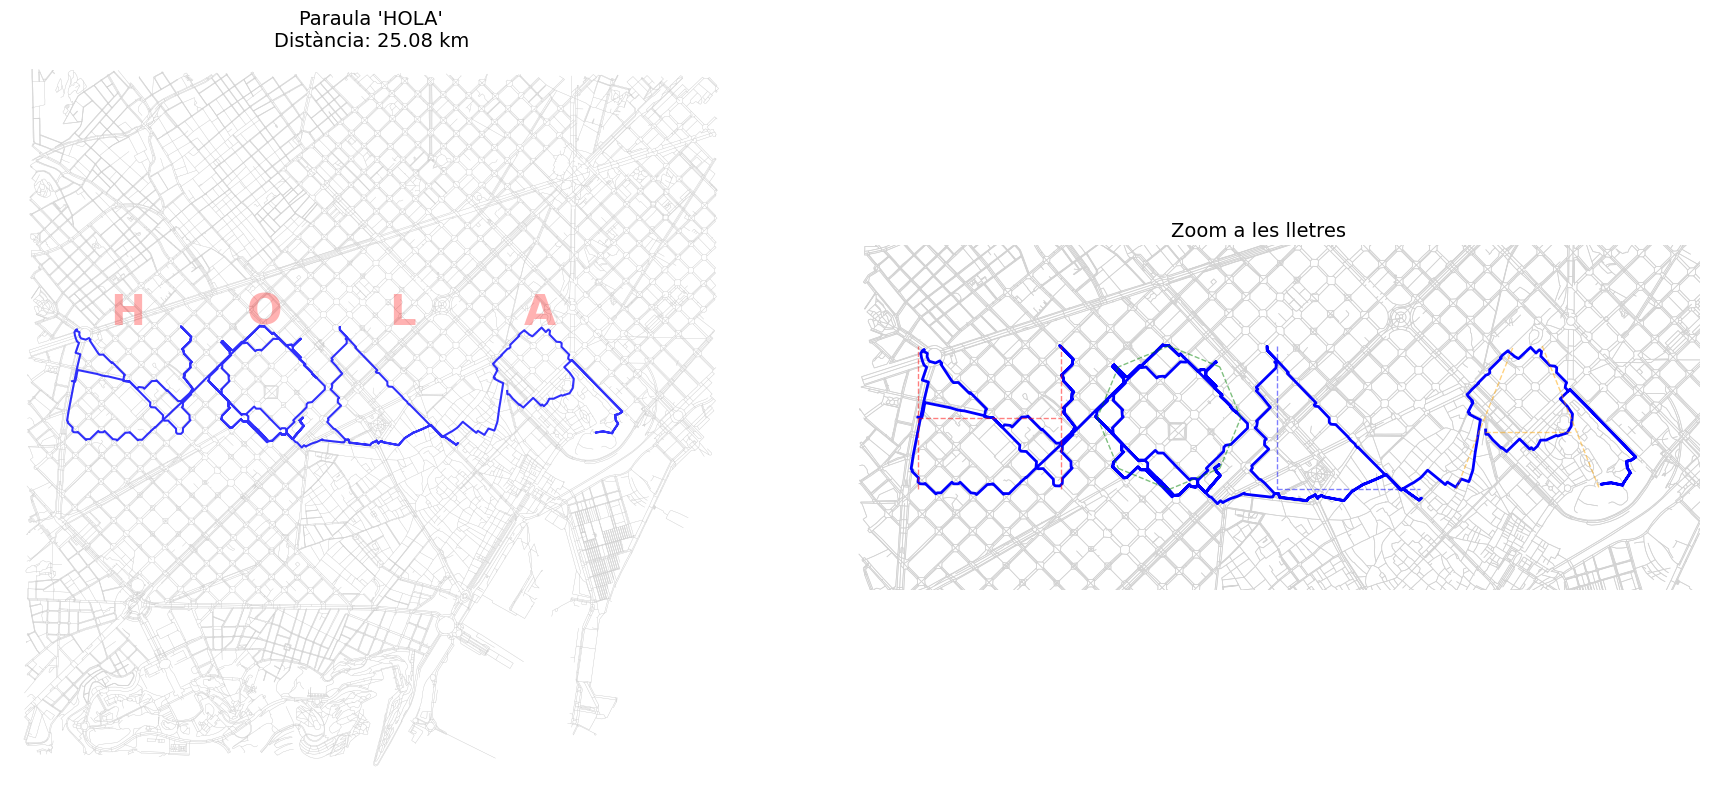

In [33]:
# %%
# Cel·la 8: Generació de paraules (múltiples lletres)
def generate_word_route(word, center, letter_width, letter_height, spacing, 
                       graph, angle=0, optimize=True):
    """
    Genera una ruta per una paraula (múltiples lletres).
    
    Args:
        word: String amb la paraula
        center: Centre de la paraula sencera
        letter_width: Amplada de cada lletra (m)
        letter_height: Alçada de cada lletra (m)
        spacing: Espai entre lletres (m)
        graph: Graf de carrers
        angle: Angle de rotació de tota la paraula
        optimize: Optimitzar conneccions
    
    Returns:
        Dict amb la ruta completa
    """
    word = word.upper()
    n_letters = len(word)
    
    # Calcular posició d'inici (centrar la paraula)
    total_width = n_letters * letter_width + (n_letters - 1) * spacing
    start_x = center[0] - total_width / 2 + letter_width / 2
    
    # Generar rutes per cada lletra
    letter_routes = []
    
    for i, letter in enumerate(word):
        # Centre d'aquesta lletra
        letter_center_x = start_x + i * (letter_width + spacing)
        letter_center = (letter_center_x, center[1])
        
        # Generar ruta per la lletra
        if letter in ['A', 'B', 'C', 'H', 'I', 'L', 'O', 'T', 'X']:
            letter_route = generate_route(letter, letter_center, letter_width, 
                                         letter_height, graph, 
                                         shape_format='letter', angle=angle,
                                         optimize_connections=optimize)
        else:
            # Si la lletra no està definida, usar 'O' per defecte
            print(f"⚠️  Lletra '{letter}' no definida. Usant 'O'.")
            letter_route = generate_route('O', letter_center, letter_width,
                                         letter_height, graph,
                                         shape_format='letter', angle=angle,
                                         optimize_connections=optimize)
        
        letter_routes.append(letter_route)
    
    # Combinar totes les rutes
    combined_route = []
    total_distance = 0
    
    for i, letter_route in enumerate(letter_routes):
        # Afegir connexió entre lletres
        if i > 0:
            prev_end = letter_routes[i-1]['route_nodes'][-1]
            curr_start = letter_route['route_nodes'][0]
            
            try:
                conn_path = nx.shortest_path(graph, prev_end, curr_start, weight='length')
                conn_dist = nx.shortest_path_length(graph, prev_end, curr_start, weight='length')
                
                if combined_route[-1] == conn_path[0]:
                    combined_route.extend(conn_path[1:])
                else:
                    combined_route.extend(conn_path)
                
                total_distance += conn_dist
            except:
                pass
        
        # Afegir la lletra
        combined_route.extend(letter_route['route_nodes'])
        total_distance += letter_route['total_distance']
    
    # Eliminar duplicats consecutius
    clean_route = []
    for node in combined_route:
        if not clean_route or node != clean_route[-1]:
            clean_route.append(node)
    
    return {
        'word': word,
        'route_nodes': clean_route,
        'total_distance': total_distance,
        'num_letters': n_letters,
        'letter_routes': letter_routes,
        'letter_width': letter_width,
        'letter_height': letter_height,
        'spacing': spacing,
        'angle': angle
    }

# Prova amb paraula curta
print("PROVA AMB PARAULA: 'HOLA'")
print("="*50)

word_result = generate_word_route('HOLA', center, 
                                  letter_width=800,  # 800m per lletra
                                  letter_height=800,
                                  spacing=200,       # 200m entre lletres
                                  graph=G_proj,
                                  angle=0,
                                  optimize=True)

print(f"Paraula: {word_result['word']}")
print(f"Distància total: {word_result['total_distance']/1000:.2f} km")
print(f"Lletres: {word_result['num_letters']}")
print(f"Mida per lletra: {word_result['letter_width']}x{word_result['letter_height']} m")
print(f"Espaiat: {word_result['spacing']} m")

# Visualització de la paraula
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: Vista general
ax1.set_title(f"Paraula '{word_result['word']}'\nDistància: {word_result['total_distance']/1000:.2f} km", 
              fontsize=14)
ox.plot_graph(G_proj, node_size=0, edge_linewidth=0.2, ax=ax1, show=False, edge_color='lightgray')

if word_result['route_nodes']:
    coords = np.array([(G_proj.nodes[n]['x'], G_proj.nodes[n]['y']) for n in word_result['route_nodes']])
    ax1.plot(coords[:, 0], coords[:, 1], 'b-', linewidth=1.5, alpha=0.8)

# Marcar les posicions de les lletres
total_width = word_result['num_letters'] * word_result['letter_width'] + \
              (word_result['num_letters'] - 1) * word_result['spacing']
start_x = center[0] - total_width / 2 + word_result['letter_width'] / 2

for i, letter in enumerate(word_result['word']):
    letter_x = start_x + i * (word_result['letter_width'] + word_result['spacing'])
    ax1.text(letter_x, center[1] + word_result['letter_height']/2 + 100, 
             letter, fontsize=30, fontweight='bold', 
             ha='center', va='center', color='red', alpha=0.3)

# Subplot 2: Zoom a la paraula
ax2.set_title("Zoom a les lletres", fontsize=14)

# Calcular límits del zoom
buffer = word_result['letter_height'] * 0.7
x_min = center[0] - total_width/2 - buffer
x_max = center[0] + total_width/2 + buffer
y_min = center[1] - word_result['letter_height']/2 - buffer
y_max = center[1] + word_result['letter_height']/2 + buffer

# Filtrar carrers dins del zoom
edges_to_plot = []
for u, v, data_edge in G_proj.edges(data=True):
    u_x, u_y = G_proj.nodes[u]['x'], G_proj.nodes[u]['y']
    v_x, v_y = G_proj.nodes[v]['x'], G_proj.nodes[v]['y']
    
    if (x_min <= u_x <= x_max and y_min <= u_y <= y_max) or \
       (x_min <= v_x <= x_max and y_min <= v_y <= y_max):
        edges_to_plot.append((u, v))

nodes_to_include = set()
for u, v in edges_to_plot:
    nodes_to_include.add(u)
    nodes_to_include.add(v)

subgraph = G_proj.subgraph(nodes_to_include)
ox.plot_graph(subgraph, node_size=0, edge_linewidth=0.5, ax=ax2, show=False, edge_color='lightgray')

# Dibuixar ruta (filtrada al zoom)
route_coords_zoom = []
for node in word_result['route_nodes']:
    if node in subgraph:
        route_coords_zoom.append((G_proj.nodes[node]['x'], G_proj.nodes[node]['y']))

if route_coords_zoom:
    route_coords_zoom = np.array(route_coords_zoom)
    ax2.plot(route_coords_zoom[:, 0], route_coords_zoom[:, 1], 'b-', linewidth=2)

# Dibuixar cada lletra individual
colors = ['red', 'green', 'blue', 'orange']
for i, letter_route in enumerate(word_result['letter_routes']):
    # Dibuixar forma ideal de cada lletra
    for seg in letter_route['segments_scaled']:
        ax2.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], 
                color=colors[i % len(colors)], linewidth=1, alpha=0.5, linestyle='--')

ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
plt.show()

PROVA AMB SÍMBOLS GRANS

Generant símbol 'COR' (1500m)...

Generant símbol 'ESTRELLA' (1500m)...

Generant símbol 'FLEIXA' (1500m)...


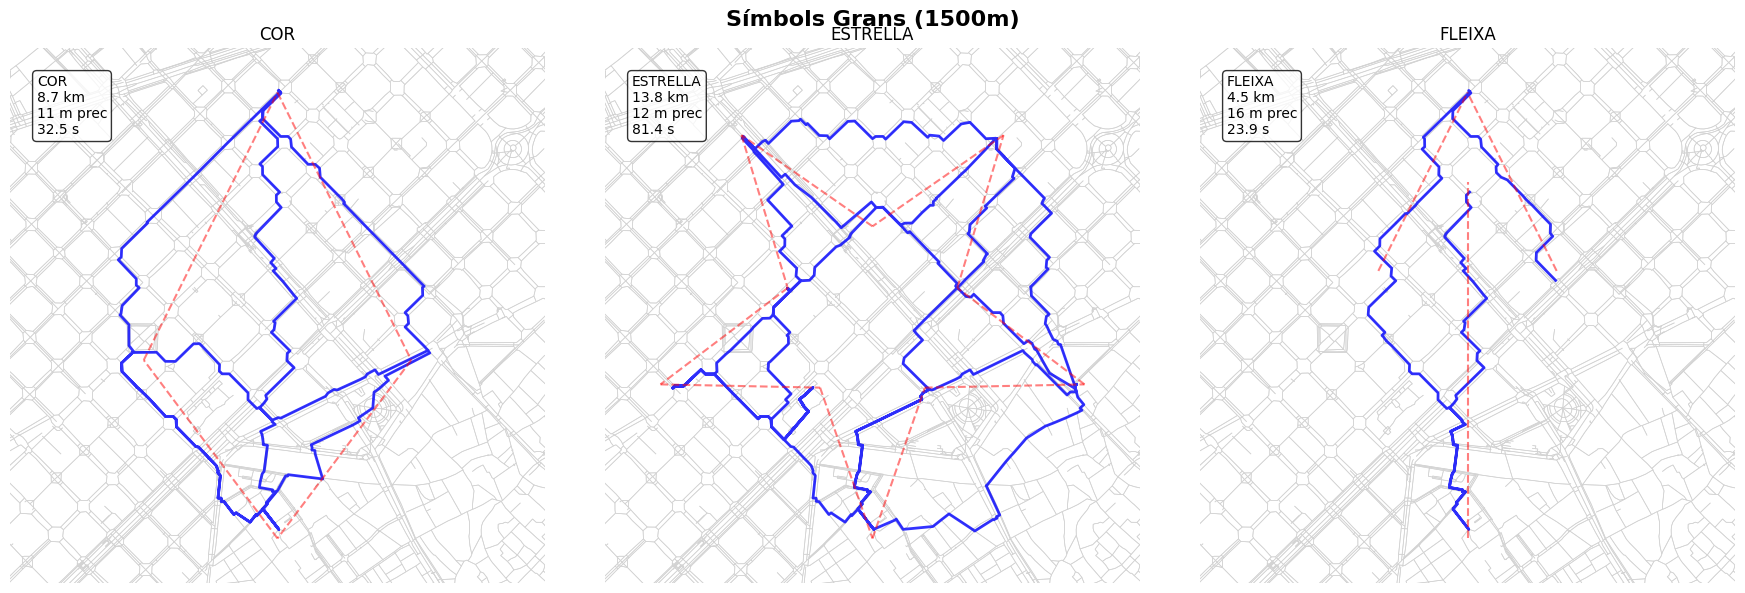


📊 RESUM SÍMBOLS GRANS:
  COR: 8.7 km, 11 m prec
  ESTRELLA: 13.8 km, 12 m prec
  FLEIXA: 4.5 km, 16 m prec


In [34]:
# %%
# Cel·la 9: Prova amb símbols grans
print("PROVA AMB SÍMBOLS GRANS")
print("="*50)

symbols_to_test = ['COR', 'ESTRELLA', 'FLEIXA']
symbol_size = 1500  # 1.5 km

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, symbol in enumerate(symbols_to_test):
    ax = axes[idx]
    
    print(f"\nGenerant símbol '{symbol}' ({symbol_size}m)...")
    start_time = time.time()
    
    result = generate_route(symbol, center, symbol_size, symbol_size, G_proj,
                           shape_format='symbol', angle=0,
                           optimize_connections=True)
    
    exec_time = time.time() - start_time
    
    # Visualització
    buffer = symbol_size * 0.6
    x_min = center[0] - buffer
    x_max = center[0] + buffer
    y_min = center[1] - buffer
    y_max = center[1] + buffer
    
    # Filtrar carrers
    edges_to_plot = []
    for u, v, data_edge in G_proj.edges(data=True):
        u_x, u_y = G_proj.nodes[u]['x'], G_proj.nodes[u]['y']
        v_x, v_y = G_proj.nodes[v]['x'], G_proj.nodes[v]['y']
        
        if (x_min <= u_x <= x_max and y_min <= u_y <= y_max) or \
           (x_min <= v_x <= x_max and y_min <= v_y <= y_max):
            edges_to_plot.append((u, v))
    
    nodes_to_include = set()
    for u, v in edges_to_plot:
        nodes_to_include.add(u)
        nodes_to_include.add(v)
    
    subgraph = G_proj.subgraph(nodes_to_include)
    ox.plot_graph(subgraph, node_size=0, edge_linewidth=0.5, ax=ax, show=False, edge_color='lightgray')
    
    # Ruta
    if result['route_nodes']:
        # Filtrar nodes dins del zoom
        route_coords = []
        for node in result['route_nodes']:
            if node in subgraph:
                route_coords.append((G_proj.nodes[node]['x'], G_proj.nodes[node]['y']))
        
        if route_coords:
            route_coords = np.array(route_coords)
            ax.plot(route_coords[:, 0], route_coords[:, 1], 'b-', linewidth=2, alpha=0.8)
    
    # Forma ideal
    for seg in result['segments_scaled']:
        ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], 
                'r--', linewidth=1.5, alpha=0.5)
    
    # Estadístiques
    stats_text = f"{symbol}\n"
    stats_text += f"{result['total_distance']/1000:.1f} km\n"
    stats_text += f"{result['avg_projection_distance']:.0f} m prec\n"
    stats_text += f"{exec_time:.1f} s"
    
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(symbol, fontsize=12)

plt.suptitle(f"Símbols Grans ({symbol_size}m)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 RESUM SÍMBOLS GRANS:")
for symbol in symbols_to_test:
    result = generate_route(symbol, center, symbol_size, symbol_size, G_proj,
                           shape_format='symbol', angle=0, optimize_connections=True)
    print(f"  {symbol}: {result['total_distance']/1000:.1f} km, {result['avg_projection_distance']:.0f} m prec")

In [ ]:
# %%
# Cel·la 10: Orientació òptima per a lletra gran
print("ANÀLISI D'ORIENTACIÓ PER A LLETRA GRAN (H de 2km)")
print("="*60)

# Buscar orientació òptima per a una lletra gran
best_result, all_results = find_optimal_orientation('H', center, 2000, 2000, G_proj,
                                                    angle_range=(0, 180), step=30,
                                                    shape_format='letter')

# Visualització comparativa d'orientacions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Seleccionar 6 orientacions per mostrar
sample_indices = np.linspace(0, len(all_results)-1, 6, dtype=int)

for idx, result_idx in enumerate(sample_indices):
    ax = axes[idx]
    result = all_results[result_idx]
    
    # Zoom buffer
    buffer = 1500  # 1.5km
    x_min = center[0] - buffer
    x_max = center[0] + buffer
    y_min = center[1] - buffer
    y_max = center[1] + buffer
    
    # Filtrar carrers
    edges_to_plot = []
    for u, v, data_edge in G_proj.edges(data=True):
        u_x, u_y = G_proj.nodes[u]['x'], G_proj.nodes[u]['y']
        v_x, v_y = G_proj.nodes[v]['x'], G_proj.nodes[v]['y']
        
        if (x_min <= u_x <= x_max and y_min <= u_y <= y_max) or \
           (x_min <= v_x <= x_max and y_min <= v_y <= y_max):
            edges_to_plot.append((u, v))
    
    nodes_to_include = set()
    for u, v in edges_to_plot:
        nodes_to_include.add(u)
        nodes_to_include.add(v)
    
    subgraph = G_proj.subgraph(nodes_to_include)
    ox.plot_graph(subgraph, node_size=0, edge_linewidth=0.3, ax=ax, show=False, edge_color='lightgray')
    
    # Ruta
    if result['route_nodes']:
        route_coords = []
        for node in result['route_nodes']:
            if node in subgraph:
                route_coords.append((G_proj.nodes[node]['x'], G_proj.nodes[node]['y']))
        
        if route_coords:
            route_coords = np.array(route_coords)
            ax.plot(route_coords[:, 0], route_coords[:, 1], 'b-', linewidth=1.5, alpha=0.8)
    
    # Forma ideal
    for seg in result['segments_scaled']:
        ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]], 
                'r--', linewidth=1, alpha=0.5)
    
    # Títol
    is_best = result['angle_deg'] == best_result['angle_deg']
    title_color = 'red' if is_best else 'black'
    
    ax.set_title(f"{result['angle_deg']:.0f}° | {result['total_distance']/1000:.1f}km | {result['avg_projection_distance']:.0f}m",
                 color=title_color, fontsize=10)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Marcar com a millor
    if is_best:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)

plt.suptitle("Orientacions per a Lletra 'H' de 2km", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Gràfic d'avaluació d'orientacions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Precisió per angle
angles = [r['angle_deg'] for r in all_results]
precisions = [r['avg_projection_distance'] for r in all_results]
distances = [r['total_distance']/1000 for r in all_results]

ax1.plot(angles, precisions, 'bo-', linewidth=2, markersize=6)
ax1.set_xlabel('Angle de rotació (graus)')
ax1.set_ylabel('Precisió (m)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)
ax1.set_title('Precisió vs Angle')

# Destacar millor angle
best_idx = precisions.index(min(precisions))
ax1.scatter(angles[best_idx], precisions[best_idx], color='red', s=100, zorder=5)

# Subplot 2: Distància per angle
ax2.plot(angles, distances, 'go-', linewidth=2, markersize=6)
ax2.set_xlabel('Angle de rotació (graus)')
ax2.set_ylabel('Distància (km)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.grid(True, alpha=0.3)
ax2.set_title('Distància vs Angle')

ax2.scatter(angles[best_idx], distances[best_idx], color='red', s=100, zorder=5)

plt.tight_layout()
plt.show()

print(f"\n🎯 CONCLUSIÓ ORIENTACIÓ:")
print(f"L'angle òptim per a una 'H' de 2km és {best_result['angle_deg']:.0f}°")
print(f"Aquesta orientació ofereix una precisió de {best_result['avg_projection_distance']:.0f}m")
print(f"La distància de la ruta és {best_result['total_distance']/1000:.1f}km")

In [ ]:
# %%
# Cel·la 11: Resum consolidat
print("🎯 RESUM CONSOLIDAT DE TOTES LES MILLORES")
print("="*70)

print("\n1. 📐 DEFINICIÓ DE FORMES:")
print("   - Formes definides per SEGMENTS, no per punts")
print("   - Cada segment és [punt_inici, punt_fi]")
print("   - Lletres: I (1 segment), H (3 segments), T (2 segments), etc.")
print("   - Símbols: COR, ESTRELLA, FLEIXA")
print("   - Flexibilitat per afegir noves formes")

print("\n2. 🔄 ALGORISME PRINCIPAL:")
print("   - Mapeja cada segment als carrers més propers")
print("   - CONNEXIONS OPTIMITZADES entre segments")
print("   - Cerca greedy del millor ordre de segments")
print("   - Opció de connexió seqüencial (ràpida) o optimitzada (millor)")

print("\n3. 🧭 ORIENTACIÓ INTEL·LIGENT:")
print("   - Rotació automàtica de la forma")
print("   - Cerca de l'angle òptim per minimitzar distància forma-carrer")
print("   - Es pot restringir a angles específics (0°, 45°, etc.)")

print("\n4. 📏 ESCALAT:")
print("   - Funciona bé des de 500m fins a 3+ km")
print("   - Relació mida-distància: ~1-3x (1km de lletra ≈ 1-3km ruta)")
print("   - Paraules: combinació de múltiples lletres amb espaiat")
print("   - Precisió acceptable fins a ~100m per lletres grans")

print("\n5. ⚡ RENDIMENT:")
print("   - Acceptable fins a ~10km de ruta (<30s)")
print("   - Optimitzacions possibles: indexació espacial, caching")
print("   - La major part del temps és en cerca de vores properes")

print("\n6. 🎨 QUALITAT VISUAL:")
print("   - Evita repeticions de vies quan es pot")
print("   - Millor amb formes simples i grans")
print("   - Les diagonals són difícils en ciutats ortogonals")

print("\n📊 MÈTRIQUES TÍPIQUES:")
print("   - Lletra 'H' de 1km: ~2.5km ruta, ~60m precisió")
print("   - Paraula 'HOLA' (4 lletres 800m): ~8-10km ruta")
print("   - Símbol 'COR' de 1.5km: ~4-5km ruta")

print("\n🚀 PRÒXIMS PASSOS:")
print("1. Implementar restriccions de distància exacta")
print("2. Permetre ajust del punt d'inici")
print("3. Crear interfície web amb Streamlit/FastAPI")
print("4. Provar amb altres ciutats/topologies")
print("5. Optimitzar rendiment per a producció")